In [5]:
import json
import pandas as pd
import numpy as np
from datetime import timedelta, datetime
font_path = "font-folder/Roboto-Regular.ttf"
font_path_bold = "font-folder/Roboto-Bold.ttf"
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt 
font_prop = fm.FontProperties(fname=font_path, size=20)
font_prop_legend = fm.FontProperties(fname=font_path, size=16)
font_prop_legend_narrow = fm.FontProperties(fname=font_path, size=11)
font_prop_title = fm.FontProperties(fname=font_path_bold, size=26)
import matplotlib as mpl
mpl.rcParams['font.family'] = font_prop.get_name()
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns



In [2]:
def compute_jaccard(list1, list2):
    """
    This function computes the Jaccard index between two lists.
    input:
        list1 = first list
        list2 = second list
    output:
        jaccard_index = Jaccard index value
    """
    set1 = set(list1)
    set2 = set(list2)
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    if len(union) == 0:  # To handle the case where both lists are empty
        return 0.0
    return len(intersection) / len(union)

In [3]:
# open json file with the dict_keep_trajs
start_date = datetime(2024, 11, 23)
end_date = datetime(2025, 4, 26)
jaccard_index_results = {}
for i, ref_date in enumerate(pd.date_range(start_date, end_date, freq='W-SAT')):
    
    if ref_date.strftime('%Y-%m-%d') == '2025-01-25':  # skip this date as there is no data for it
        continue
    print(f"Processing reference date: {ref_date.strftime('%Y-%m-%d')}, with index: {i}")
    with open(f"../output_data/persistance_metrics_rmse_wmape/dict_keep_trajs_Ens2_S2_LOP_rmse_2024-2025.json", "r") as f:
        dict_keep_trajs_rmse = json.load(f)
    with open(f"../output_data/persistance_metrics_rmse_wmape/dict_keep_trajs_Ens2_S2_LOP_wmape_2024-2025.json", "r") as g:
        dict_keep_trajs_wmape = json.load(g)
    jaccard_index_kbests = {}
    for k_best, traj_list in dict_keep_trajs_rmse.items():
        traj_list_wmape = dict_keep_trajs_wmape[k_best][i]
        traj_list_rmse = dict_keep_trajs_rmse[k_best][i]
        # compute jaccard similarity between the two lists of trajectories
        jaccard_index_value = compute_jaccard(traj_list_rmse, traj_list_wmape)
        jaccard_index_kbests[k_best] = jaccard_index_value
    jaccard_index_results[ref_date.strftime('%Y-%m-%d')] = jaccard_index_kbests
jaccard_index_results

Processing reference date: 2024-11-23, with index: 0
Processing reference date: 2024-11-30, with index: 1
Processing reference date: 2024-12-07, with index: 2
Processing reference date: 2024-12-14, with index: 3
Processing reference date: 2024-12-21, with index: 4
Processing reference date: 2024-12-28, with index: 5
Processing reference date: 2025-01-04, with index: 6
Processing reference date: 2025-01-11, with index: 7
Processing reference date: 2025-01-18, with index: 8
Processing reference date: 2025-02-01, with index: 10
Processing reference date: 2025-02-08, with index: 11
Processing reference date: 2025-02-15, with index: 12
Processing reference date: 2025-02-22, with index: 13
Processing reference date: 2025-03-01, with index: 14
Processing reference date: 2025-03-08, with index: 15
Processing reference date: 2025-03-15, with index: 16
Processing reference date: 2025-03-22, with index: 17
Processing reference date: 2025-03-29, with index: 18
Processing reference date: 2025-04-05

{'2024-11-23': {'0.05': 0.7640232108317214,
  '0.15': 0.8083278255122274,
  '0.25': 0.8124006359300477,
  '0.5': 0.8811881188118812,
  '0.75': 0.9374026341877921},
 '2024-11-30': {'0.05': 0.7272727272727273,
  '0.15': 0.7952755905511811,
  '0.25': 0.8536585365853658,
  '0.5': 0.9260823653643083,
  '0.75': 0.9523333809048095},
 '2024-12-07': {'0.05': 0.805940594059406,
  '0.15': 0.8424242424242424,
  '0.25': 0.8944744495222269,
  '0.5': 0.927710843373494,
  '0.75': 0.9582021185227598},
 '2024-12-14': {'0.05': 0.7847358121330724,
  '0.15': 0.8624914908100749,
  '0.25': 0.9,
  '0.5': 0.9338422391857506,
  '0.75': 0.9573615681785663},
 '2024-12-21': {'0.05': 0.7777777777777778,
  '0.15': 0.873972602739726,
  '0.25': 0.9015846538782318,
  '0.5': 0.9371282922684792,
  '0.75': 0.9652348800459704},
 '2024-12-28': {'0.05': 0.805940594059406,
  '0.15': 0.8474004051316678,
  '0.25': 0.8889809444904723,
  '0.5': 0.9387755102040817,
  '0.75': 0.9689119170984456},
 '2025-01-04': {'0.05': 0.497536945

In [4]:
# create a dataframe from the jaccard_index_results dictionary
jaccard_index_df = pd.DataFrame.from_dict(jaccard_index_results, orient='index')
jaccard_index_df.index = pd.to_datetime(jaccard_index_df.index)
jaccard_index_df.sort_index(inplace=True)
jaccard_index_df

,0.05,0.15,0.25,0.5,0.75
2024-11-23,0.764023,0.808328,0.812401,0.881188,0.937403
2024-11-30,0.727273,0.795276,0.853659,0.926082,0.952333
2024-12-07,0.805941,0.842424,0.894474,0.927711,0.958202
2024-12-14,0.784736,0.862491,0.900000,0.933842,0.957362
2024-12-21,0.777778,0.873973,0.901585,0.937128,0.965235
2024-12-28,0.805941,0.847400,0.888981,0.938776,0.968912
2025-01-04,0.497537,0.674419,0.788937,0.932203,0.962416
2025-01-11,0.543147,0.631485,0.719457,0.931794,0.954565
2025-01-18,0.600000,0.663222,0.753846,0.944978,0.957642
2025-02-01,0.661202,0.778934,0.831325,0.946223,0.965235


In [11]:
jaccard_index_df_melted = jaccard_index_df.melt(var_name='k_best', value_name='jaccard_index')
jaccard_index_df_melted

,k_best,jaccard_index
0,0.05,0.764023
1,0.05,0.727273
2,0.05,0.805941
3,0.05,0.784736
4,0.05,0.777778
...,...,...
105,0.75,0.960166
106,0.75,0.959885
107,0.75,0.958482
108,0.75,0.957362


In [12]:
print(jaccard_index_df_melted['k_best'].unique())

['0.05' '0.15' '0.25' '0.5' '0.75']


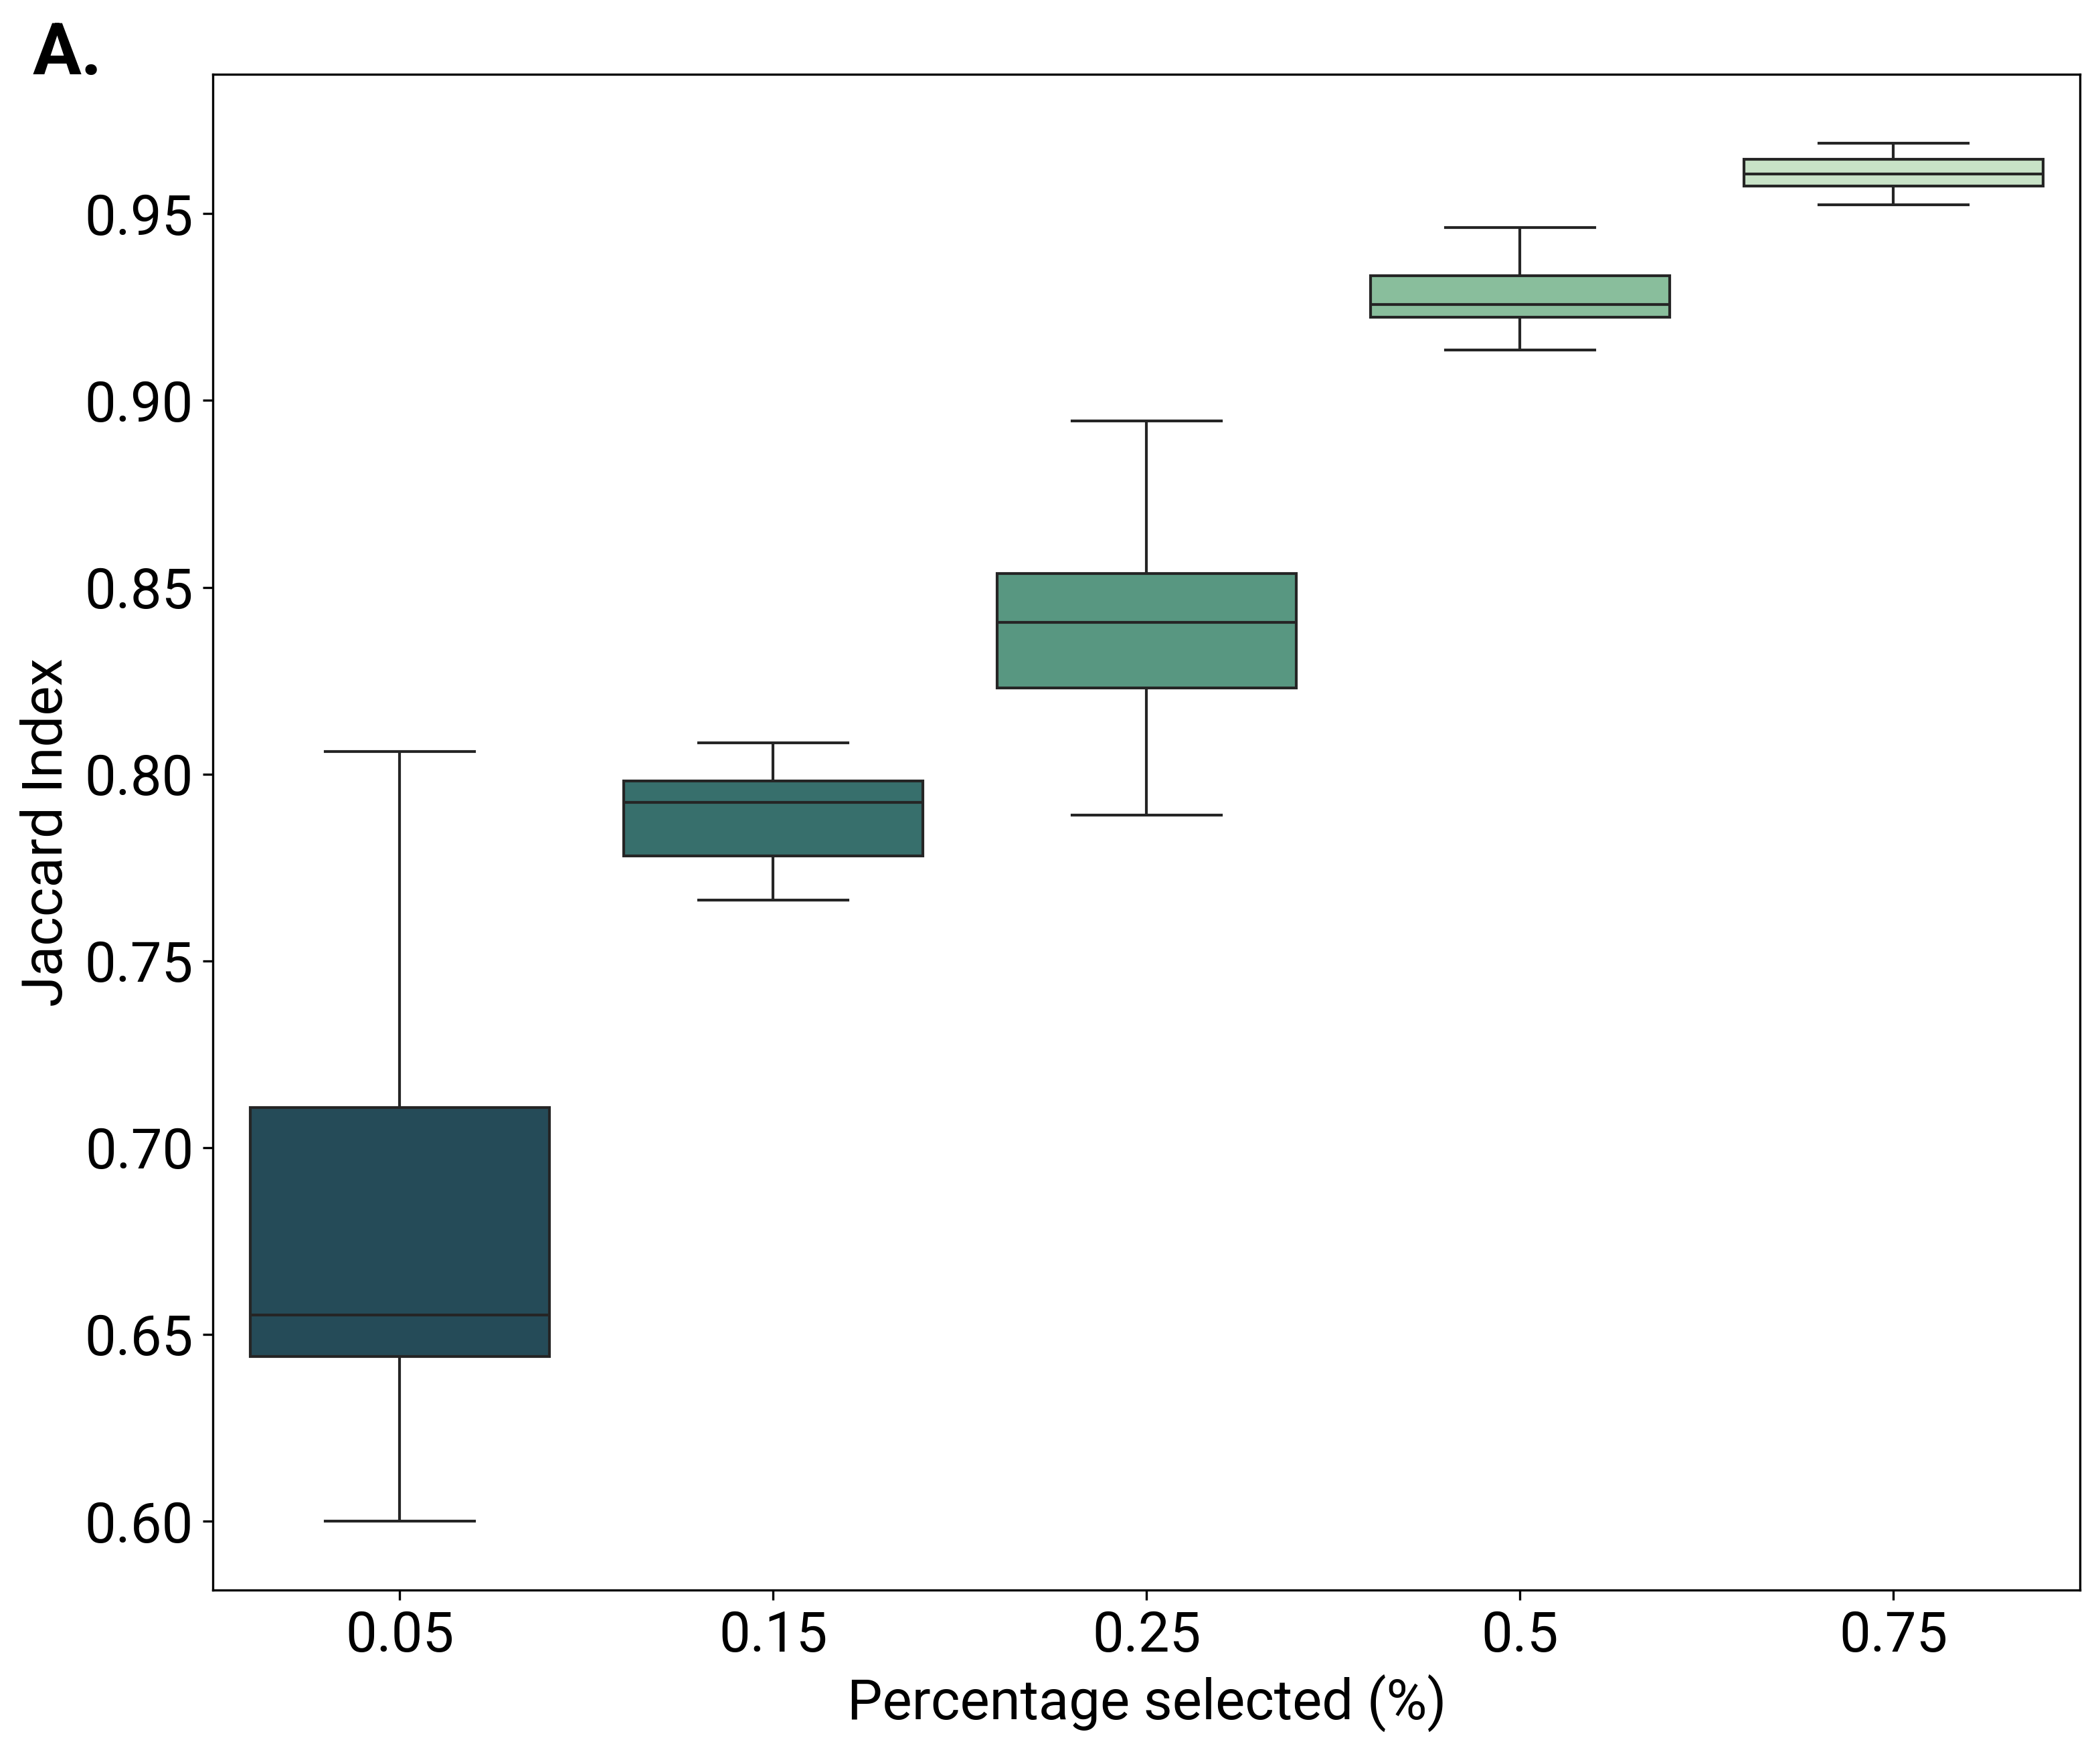

In [19]:
# boxplot with seaborn with x axis as the k_best and y axis as the jaccard index value

palette = {
    '0.05': '#1d4f60',
    '0.15': '#2d7974',
    '0.25': '#4da284',
    '0.5': '#80c799',
    '0.75': '#c4e6c3'
}
# melt the dataframe to have a long format for seaborn
fig, ax = plt.subplots(figsize=(12, 10), dpi = 300)
sns.boxplot(x='k_best', y='jaccard_index', data=jaccard_index_df_melted, 
            palette=palette, showfliers=False, ax=ax)
ax.set_xlabel('Percentage selected (%)', fontproperties=font_prop)
ax.set_ylabel('Jaccard Index', fontproperties=font_prop)
# label as fontproperties
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
fig.text(0.05, 0.88, 'A.', font_properties=font_prop_title)
plt.show()